# Convoluciones personalizadas

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Cargado de la imagen en escala de grises

Como primera medida se hace el cargado de la imagen en escala de grises.

In [57]:
imagen = cv2.imread("../media/imagenprueba.png", cv2.IMREAD_GRAYSCALE)

if imagen is None:
    raise Exception("La imagen indicada no existe, verifique la ruta de archivo especificada.")

### Definición de kernels

Definición de los Kernels que van a ser utilizados en la imagen

##### Kernel Sharpen

Utilizado para resaltar bordes, mejorar los detalles y aumentar el contraste.
El filtro toma el valor del pixel central lo multiplica por un valor bastante alto, en este caso 5 y resta los valores de sus vecinos adyacentes.

In [58]:
kernel_sharpen = np.array(
    [[0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]]
)

##### Kernel Blur

Suavizan la imagen promediando los valores de los pixeles vecinos eliminando el ruido. 
Para este caso se va a utilizar un box blur que asigna el mismo peso a todos los pixeles de la vecindad

In [59]:
kernel_blur = (1/9) * np.array(
    [[1, 1, 1],
     [1, 1, 1],
     [1, 1, 1]]
)

##### Sobels

Se usan de forma principal para la detección de bordes. Estos usan dos matrices una para bordes verticales y otros para horizontales.

In [60]:
kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

In [61]:
kernel_sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

### Función de convolución

Se pretende implementar una funci+on de convolución que reciba dos parámetros, el primero la imagen y el segundo el kernel que se pretende aplicar sobre esta imagen.

Pasos de la función: 
1. Definición de las dimensiones de la imagen de input y del kernel. El tamaño del kernel será importante puesto que este definirá el padding que será necesario aplicar a la imagen para poder desarrollar la convolución sin problema.
2. Definición del padding necesario y agregar el padding con zeros
3. Recorrer la imagen multiplicando el kernel y sumando el valor resultante.

In [62]:
def convolucion(imagen, kernel):
    alto_imagen, ancho_imagen = imagen.shape
    alto_kernel, ancho_kernel = kernel.shape

    padding_y = alto_kernel // 2
    padding_x = ancho_kernel // 2

    imagen_padded = np.pad(
        imagen,
        ((padding_y, padding_y), (padding_x, padding_x)),
        mode='constant'
        
    )

    resultado = np.zeros_like(imagen)

    for y in range(alto_imagen):
        for x in range(ancho_imagen):
            region = imagen_padded[
                y:y+alto_kernel,
                x:x+ancho_kernel
            ]

            valor = np.sum(region * kernel)
            valor = np.clip(valor, 0, 255)

            resultado[y, x] = valor
    
    return resultado.astype(np.uint8)

### Aplicación de convoluciones en la imagen

In [63]:
imagen_sharpen = convolucion(imagen, kernel_sharpen)
imagen_blur = convolucion(imagen, kernel_blur)
sobel_x = convolucion(imagen, kernel_sobel_x)
sobel_y = convolucion(imagen, kernel_sobel_y)

### Detección de bordes

In [64]:
bordes = np.sqrt(
    sobel_x.astype(np.float32)**2 +
    sobel_y.astype(np.float32)**2
)

bordes = np.clip(bordes, 0, 255).astype(np.uint8)

### Operaciones con OpenCV

Con el fin de comparar se pretende aplicar los mismo filtros, ya no de forma manual, sino que haciendo uso de las funciones de OpenCV.

In [65]:
ocv_sharpen = cv2.filter2D(imagen, -1, kernel_sharpen)
ocv_blur = cv2.filter2D(imagen, -1, kernel_blur)
ocv_sobel_x = cv2.Sobel(imagen, cv2.CV_64F, 1, 0, ksize=3)
ocv_sobel_y = cv2.Sobel(imagen, cv2.CV_64F, 0, 1, ksize=3)
ocv_bordes = np.sqrt(ocv_sobel_x**2 + ocv_sobel_y**2)
ocv_bordes = np.clip(ocv_bordes, 0, 255).astype(np.uint8)

### Visualización de resultados
Para la visualización de resultados, se pretende comparar todas las imagenes generadas con la original y con sus filtros definidos por el kernel dado.

In [66]:
titulos = [
    "Original",
    "Sharpen Manual",
    "Blur Manual",
    "Bordes Manual",
    "Sharpen OpenCV",
    "Blur OpenCV",
    "Bordes OpenCV"
]

In [67]:
imagenes = [
    imagen,
    imagen_sharpen,
    imagen_blur,
    bordes,
    ocv_sharpen,
    ocv_blur,
    ocv_bordes
]

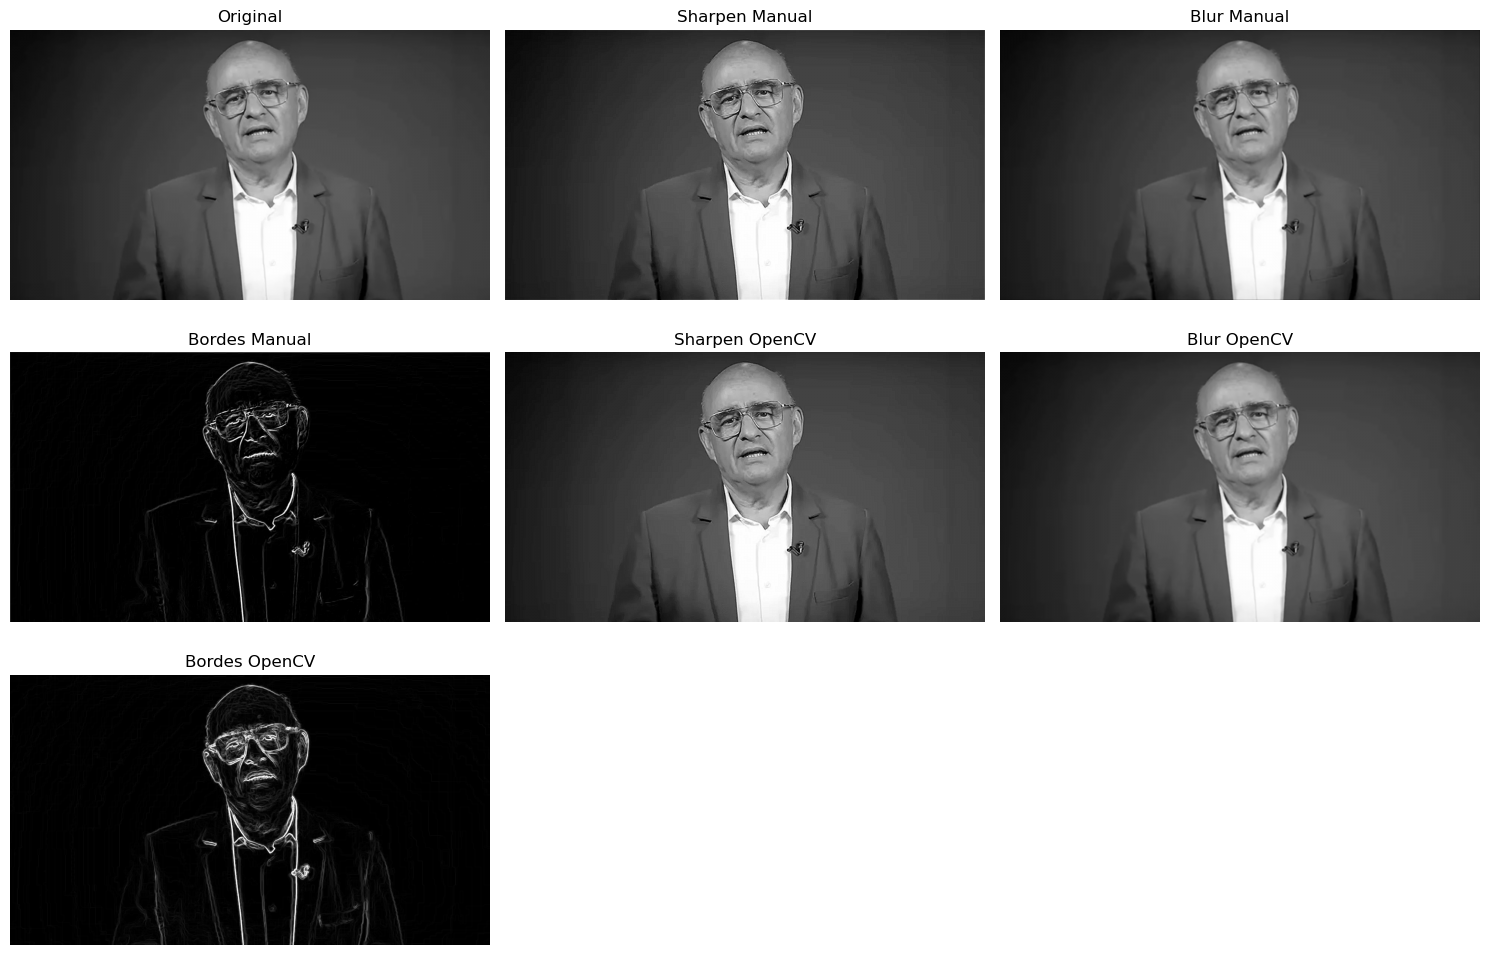

In [68]:
plt.figure(figsize=(15,10))

for i in range(len(imagenes)):
    plt.subplot(3,3,i+1)
    plt.imshow(imagenes[i], cmap='gray')
    plt.title(titulos[i])
    plt.axis("off")

plt.tight_layout()

plt.show()